# **Day 89: Project 1 - Land Use / Land Cover Mapping (Part 1): Study Area, Reference Data and Features**
*Module 13 - Remote Sensing ML and Publication Projects*

Days 89-91 are one complete, publication-style study, built the way we would build a paper:

> **Working title**: *Multi-season Sentinel-1/2 and machine learning for land-cover mapping in a coal-mining landscape of the Damodar valley: a spatially validated comparison with design-based area estimates.*

| Day | Paper section | Output |
|---|---|---|
| 89 (today) | Study area, data, reference data, features | Fig. 1 (study area), Table 1 (reference data), Fig. 2 (signatures), training table, feature module |
| 90 | Methods and results: model comparison | Table 2 (spatial CV), Table 3 (feature-group ablation), significance tests, tuned final model |
| 91 | Results: map, accuracy, areas, interpretation | Fig. 3 (map), Table 4 (accuracy and areas with CIs), AOA, SHAP, all figures at 300 dpi |

**Research questions**
- **RQ1**: Which classifier (RF, SVM, XGBoost, LightGBM, MLP) gives the most accurate map under spatial cross-validation, and are the differences significant?
- **RQ2**: How much do Sentinel-1, multi-season information, texture and terrain add to Sentinel-2 single-date features?
- **RQ3**: What is the area of each land-cover class, with 95% confidence intervals, after bias correction?

The data are the simulated Day 86/87 scene. Replace `data/study_area` with our own GEE exports (Day 87) and the code runs unchanged.

> The first part of the land-cover project prepares everything a paper needs before modelling: a study-area map, checked reference data, and a well-designed set of features from several seasons and sensors.
>
> *Example:* Forest and shrub may look similar in one image, but forest stays green in the dry season while shrub turns brown. Seasonal features capture that difference.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd, rasterio, json, sys
from pathlib import Path
from pyproj import Transformer
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
import rs_utils as ru
ru.pub_style()

## **1. A Reproducible Project Layout**
Every number and figure in the paper must be regenerable from raw data with one command. Start with a fixed folder structure and a single configuration file holding every choice that a reviewer might ask about.

```
project1_lulc/
  config.json              <- all parameters (seeds, CRS, classes, CV, paths)
  lulc_features.py         <- feature engineering, imported by every notebook
  data/                    <- derived data (training table, feature lists)
  models/                  <- fitted models
  outputs/figures/         <- Fig. 1-n at 300 dpi
  outputs/tables/          <- Table 1-n as CSV
```

In [2]:
PROJ = Path("project1_lulc")
for sub in ["data", "models", "outputs/figures", "outputs/tables"]:
    (PROJ / sub).mkdir(parents=True, exist_ok=True)
config = {
    "project": "LULC mapping, Damodar valley (simulated)",
    "raw_data_dir": "data/study_area", "crs": ru.CRS, "pixel_size_m": 20, "seed": 42,
    "classes": ru.LC_CLASSES, "class_colors": ru.LC_COLORS,
    "cv": {"type": "spatial_block", "block_size_m": 2000, "n_folds": 5},
    "validation": {"design": "stratified random by map class", "target_se_oa": 0.01, "n_rare_class": 75},
    "corr_threshold": 0.95,
}
(PROJ / "config.json").write_text(json.dumps(config, indent=2))
RAW = Path(config["raw_data_dir"])
print((PROJ / "config.json").read_text()[:400], "...")

{
  "project": "LULC mapping, Damodar valley (simulated)",
  "raw_data_dir": "data/study_area",
  "crs": "EPSG:32645",
  "pixel_size_m": 20,
  "seed": 42,
  "classes": [
    "water",
    "forest",
    "cropland",
    "built_up",
    "mining_bare",
    "shrub_grass"
  ],
  "class_colors": [
    "#2b83ba",
    "#1a9641",
    "#f4d03f",
    "#d7191c",
    "#5d4037",
    "#a6d96a"
  ],
  "cv": {
    " ...


## **2. Study Area (Fig. 1)**
A good study-area figure shows **where** (geographic context and coordinates), **what** (an image composite) and the **controls** (terrain), with a scale bar, a north arrow, a coordinate grid and a legend. Location insets normally use national and state boundaries (Natural Earth or GADM with `geopandas`). Offline, we print the geographic extent instead.

extent: 86.313-86.411 E, 23.780-23.870 N | 10 x 10 km | CRS EPSG:32645


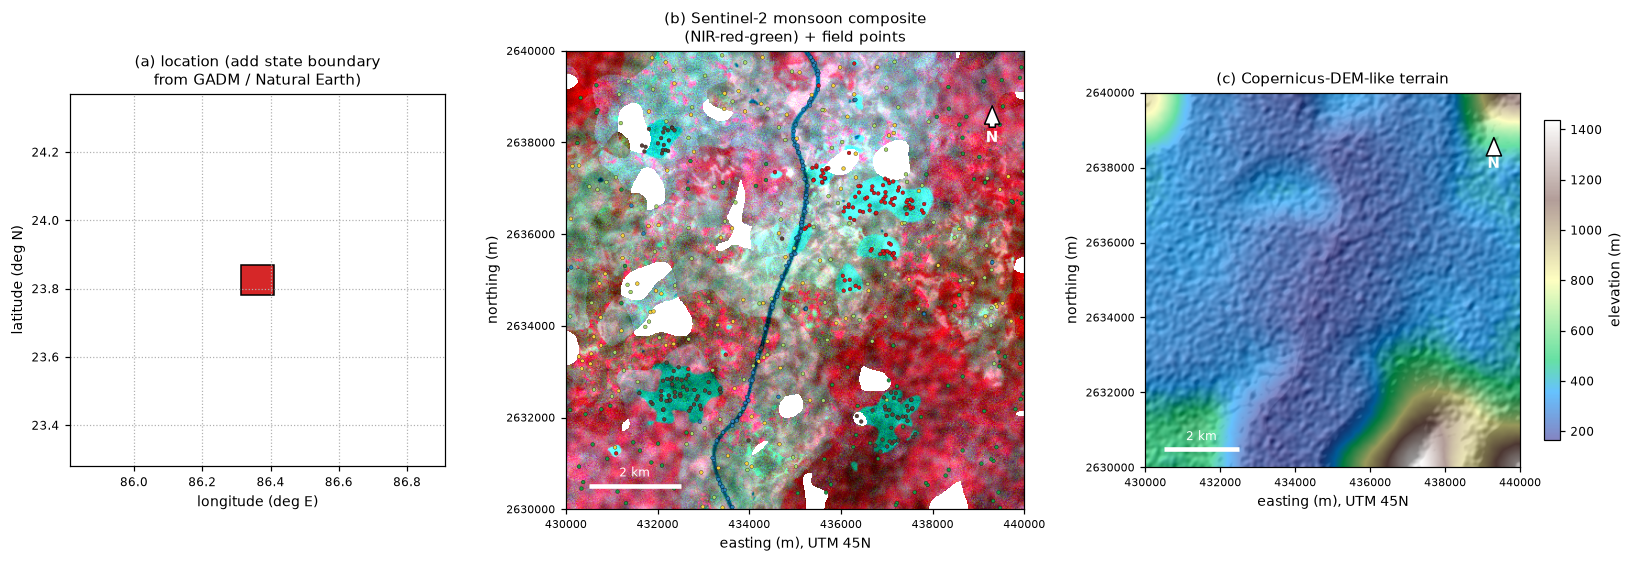

In [3]:
with rasterio.open(RAW / "feature_stack_2024.tif") as src:
    T, shape, crs = src.transform, (src.height, src.width), src.crs
    bnames = list(src.descriptions); b = lambda n: src.read(bnames.index(n) + 1)
    fcc = np.dstack([b("monsoon_B8"), b("monsoon_B4"), b("monsoon_B3")])
    dem = b("elevation_m")
ext = ru.map_extent(T, shape)
to_ll = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
(lon0, lat0), (lon1, lat1) = to_ll.transform(ext[0], ext[2]), to_ll.transform(ext[1], ext[3])
print(f"extent: {lon0:.3f}-{lon1:.3f} E, {lat0:.3f}-{lat1:.3f} N | {(ext[1] - ext[0]) / 1000:.0f} x {(ext[3] - ext[2]) / 1000:.0f} km | CRS {crs}")

def stretch(img, lo=2, hi=98):
    p = np.nanpercentile(img, [lo, hi], axis=(0, 1)); return np.clip((img - p[0]) / (p[1] - p[0]), 0, 1)

field = gpd.read_file(RAW / "field_points.gpkg")
fig, axes = plt.subplots(1, 3, figsize=(15, 5), gridspec_kw={"width_ratios": [0.8, 1, 1]})
ax = axes[0]
ax.add_patch(plt.Rectangle((lon0, lat0), lon1 - lon0, lat1 - lat0, fc="tab:red", ec="k"))
ax.set_xlim(lon0 - 0.5, lon1 + 0.5); ax.set_ylim(lat0 - 0.5, lat1 + 0.5); ax.set_aspect("equal"); ax.grid(ls=":")
ax.set_xlabel("longitude (deg E)"); ax.set_ylabel("latitude (deg N)")
ax.set_title("(a) location (add state boundary\nfrom GADM / Natural Earth)")
axes[1].imshow(stretch(fcc), extent=ext); axes[1].set_title("(b) Sentinel-2 monsoon composite\n(NIR-red-green) + field points")
cmap, norm = ru.categorical_cmap()
axes[1].scatter(field.geometry.x, field.geometry.y, c=field["class_id"], cmap=cmap, norm=norm, s=6, edgecolors="k", linewidths=0.2)
dy, dx = np.gradient(dem, 20); hs = np.clip(0.6 + 0.4 * (-dx - dy) / np.hypot(dx, dy).max() * 4, 0, 1)
axes[2].imshow(hs, cmap="gray", extent=ext); im = axes[2].imshow(dem, cmap="terrain", alpha=0.6, extent=ext)
fig.colorbar(im, ax=axes[2], shrink=0.7, label="elevation (m)"); axes[2].set_title("(c) Copernicus-DEM-like terrain")
for ax in axes[1:]:
    ru.add_scalebar(ax, 2000, ext, color="w"); ru.add_north_arrow(ax, color="w")
    ax.ticklabel_format(style="plain"); ax.tick_params(labelsize=7); ax.set_xlabel("easting (m), UTM 45N"); ax.set_ylabel("northing (m)")
plt.tight_layout(); fig.savefig(PROJ / "outputs/figures/fig1_study_area.png", dpi=300, bbox_inches="tight"); plt.show()

## **3. Reference Data Audit (Table 1)**
The field data are 600 points from Day 86. They were collected by stratified random sampling on a prior land-cover map (in practice ESA WorldCover or Dynamic World), and recorded with a handheld GPS (about 8 m error). Before modelling, audit them:
- class counts and the minimum per class
- points falling in the **same pixel** (duplicates inflate CV)
- spatial distribution: how many spatial blocks each class occupies
- **label quality**: points whose label disagrees strongly with a cross-validated model

In [4]:
r, c = ru.points_to_rowcol(T, field.geometry.x.values, field.geometry.y.values)
field["row"], field["col"] = r, c
field["block"] = ru.spatial_blocks(field.geometry.x.values, field.geometry.y.values, config["cv"]["block_size_m"])
dup = field.duplicated(["row", "col"], keep="first")
print(f"{dup.sum()} points share a pixel with another point -> dropped")
field = field[~dup].reset_index(drop=True)
table1 = field.groupby("class").agg(n_points=("point_id", "size"), n_blocks=("block", "nunique")).reindex(ru.LC_CLASSES)
table1["share_%"] = (100 * table1.n_points / table1.n_points.sum()).round(1)
table1.to_csv(PROJ / "outputs/tables/table1_reference_data.csv"); table1

2 points share a pixel with another point -> dropped


,n_points,n_blocks,share_%
class,,,
water,97,11,16.2
forest,99,18,16.6
cropland,100,20,16.7
built_up,99,8,16.6
mining_bare,100,10,16.7
shrub_grass,103,21,17.2


## **4. Features: a Shared Module**
Feature code that lives in three notebooks will drift apart. We write it **once** to `project1_lulc/lulc_features.py` (with `%%writefile`) and import it in Days 89, 90 and 91.

Feature groups (used for the ablation study in Day 90):
| Group | Features |
|---|---|
| `S2_monsoon` | 10 bands of the monsoon composite (the "single-date" baseline) |
| `S2_multiseason` | bands of the other three seasons |
| `S2_index` | NDVI, MNDWI, NDBI, NDRE, BSI per season |
| `temporal` | NDVI max, min, amplitude, s.d., peak season; MNDWI max |
| `S1` | VV, VH and VH-VV (dB) for monsoon and winter |
| `texture` | local s.d. and local semivariance (a GLCM-contrast analogue) of monsoon NIR and NDVI |
| `terrain` | elevation, slope, northness, eastness |

Aspect is circular (359 deg is next to 1 deg), so we encode it as northness = cos(aspect) x sin(slope) and eastness = sin(aspect) x sin(slope). Distance to roads or towns would be a strong location proxy; we leave it out so that the map reflects land cover, not proximity.

In [5]:
%%writefile project1_lulc/lulc_features.py
"""Feature engineering for Project 1 (LULC). Written by Day 89 and imported by Days 90-91."""
import numpy as np
import rasterio
from scipy.ndimage import uniform_filter

SEASONS = ["winter", "premonsoon", "monsoon", "postmonsoon"]
INDICES = ["NDVI", "MNDWI", "NDBI", "NDRE", "BSI"]
S2_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

def local_std(a, size):
    m = uniform_filter(a, size)
    return np.sqrt(np.clip(uniform_filter(a * a, size) - m * m, 0, None))

def local_semivariance(a, size):
    """Mean half squared difference between horizontally / vertically adjacent pixels in a window.
    For continuous data this is what the GLCM 'contrast' measures for a lag of one pixel."""
    dx = np.zeros_like(a); dx[:, :-1] = (a[:, 1:] - a[:, :-1]) ** 2
    dy = np.zeros_like(a); dy[:-1] = (a[1:] - a[:-1]) ** 2
    return 0.5 * uniform_filter(0.5 * (dx + dy), size)

def build_feature_stack(raw_dir):
    """Return (features (F, H, W) float32, names, groups, gap_mask (H, W), rasterio profile)."""
    with rasterio.open(f"{raw_dir}/feature_stack_2024.tif") as src:
        base = src.read().astype(np.float32); names = list(src.descriptions); profile = src.profile
    gap = np.isnan(base).any(0)                                    # pixels with no clear observation in some season
    med = np.nanmedian(base.reshape(len(base), -1), axis=1)
    for i in range(len(base)):                                     # gap filling: band median (documented in the paper)
        base[i][np.isnan(base[i])] = med[i]
    get = lambda n: base[names.index(n)]
    feats, fnames, groups = [], [], []

    def add(a, n, g):
        feats.append(np.asarray(a, np.float32)); fnames.append(n); groups.append(g)

    for s in SEASONS:
        for bnd in S2_BANDS:
            add(get(f"{s}_{bnd}"), f"{s}_{bnd}", "S2_monsoon" if s == "monsoon" else "S2_multiseason")
        for ix in INDICES:
            add(get(f"{s}_{ix}"), f"{s}_{ix}", "S2_index")
    ndvi = np.stack([get(f"{s}_NDVI") for s in SEASONS])
    add(ndvi.max(0), "NDVI_max", "temporal"); add(ndvi.min(0), "NDVI_min", "temporal")
    add(ndvi.max(0) - ndvi.min(0), "NDVI_amplitude", "temporal"); add(ndvi.std(0), "NDVI_sd", "temporal")
    add(np.argmax(ndvi, 0), "NDVI_peak_season", "temporal")
    add(np.max([get(f"{s}_MNDWI") for s in SEASONS], 0), "MNDWI_max", "temporal")
    for s in ["monsoon", "winter"]:
        add(get(f"{s}_VV"), f"{s}_VV", "S1"); add(get(f"{s}_VH"), f"{s}_VH", "S1")
        add(get(f"{s}_VH") - get(f"{s}_VV"), f"{s}_VHminusVV", "S1")
    nir, nd = get("monsoon_B8"), get("monsoon_NDVI")
    for size in (3, 7):
        add(local_std(nir, size), f"tex_B8_sd{size}", "texture"); add(local_semivariance(nir, size), f"tex_B8_semivar{size}", "texture")
    add(local_std(nd, 7), "tex_NDVI_sd7", "texture")
    slope, aspect = np.radians(get("slope_deg")), np.radians(get("aspect_deg"))
    add(get("elevation_m"), "elevation_m", "terrain"); add(get("slope_deg"), "slope_deg", "terrain")
    add(np.cos(aspect) * np.sin(slope), "northness", "terrain"); add(np.sin(aspect) * np.sin(slope), "eastness", "terrain")
    return np.stack(feats), fnames, groups, gap, profile

Writing project1_lulc/lulc_features.py


In [6]:
sys.path.insert(0, str(PROJ))
import lulc_features as lf
F, fnames, fgroups, gap, profile = lf.build_feature_stack(RAW)
print(f"feature stack {F.shape}, {F.nbytes / 1e6:.0f} MB in memory; gap-filled pixels: {gap.mean():.2%}")
print(pd.Series(fgroups).value_counts().to_dict())

feature stack (81, 500, 500), 81 MB in memory; gap-filled pixels: 4.76%
{'S2_multiseason': 30, 'S2_index': 20, 'S2_monsoon': 10, 'temporal': 6, 'S1': 6, 'texture': 5, 'terrain': 4}


## **5. The Training Table**
We extract the features at the reference pixels and store the coordinates and the spatial block of each point. The coordinates are not used as predictors; we keep them for spatial CV and for maps.

In [7]:
X = F[:, field["row"], field["col"]].T
train = pd.concat([field[["point_id", "class_id", "class", "row", "col", "block"]], pd.DataFrame(X, columns=fnames)], axis=1)
train["x"], train["y"] = field.geometry.x.values, field.geometry.y.values
train.to_csv(PROJ / "data/training_table.csv", index=False)
print(train.shape, "->", PROJ / "data/training_table.csv")
train.groupby("class")[["monsoon_NDVI", "winter_NDVI", "NDVI_amplitude", "monsoon_VH", "MNDWI_max", "tex_B8_sd7", "slope_deg"]].median().round(3)

(598, 89) -> project1_lulc\data\training_table.csv


,monsoon_NDVI,winter_NDVI,NDVI_amplitude,monsoon_VH,MNDWI_max,tex_B8_sd7,slope_deg
class,,,,,,,
built_up,0.164,0.176,0.101,-12.312000,-0.220,0.018,4.460
cropland,0.501,0.470,0.324,-20.048000,-0.316,0.024,2.842
forest,0.677,0.639,0.218,-14.301000,-0.318,0.016,11.528
mining_bare,0.103,0.092,0.142,-19.341999,-0.156,0.013,7.958
shrub_grass,0.500,0.366,0.244,-16.469000,-0.332,0.017,6.085
water,-0.085,-0.044,0.292,-28.395000,0.437,0.095,5.578


## **6. Spectral-Temporal Signatures (Fig. 2)**
Plot class medians with interquartile ranges. Reviewers look for **why** classes are separable, and in which season.

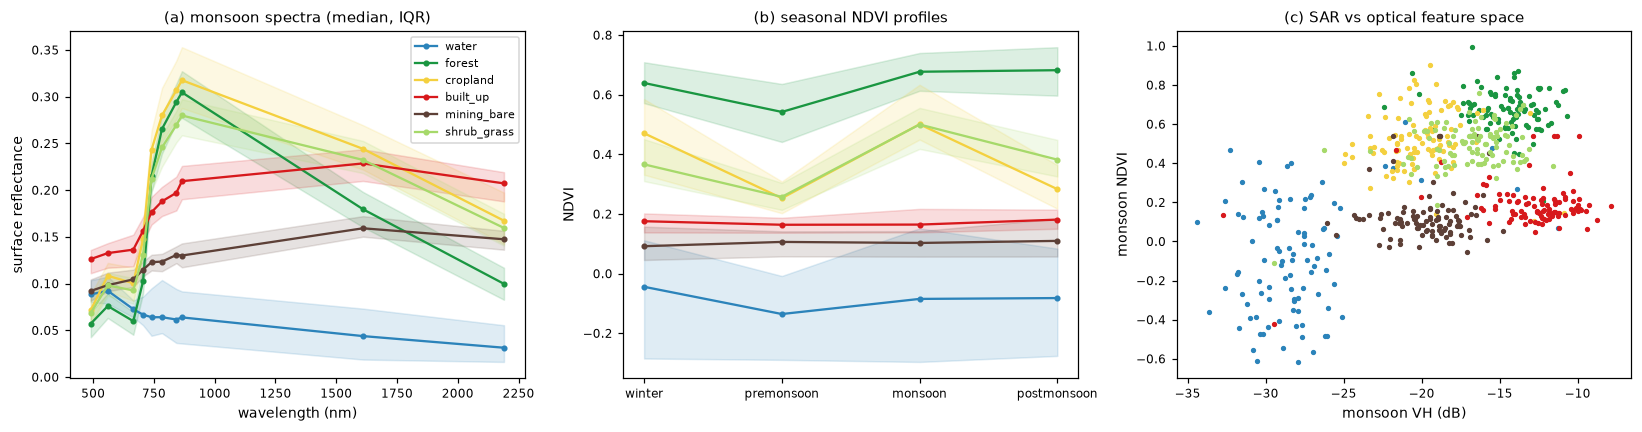

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
wl = [490, 560, 665, 705, 740, 783, 842, 865, 1610, 2190]
for k, cl in enumerate(ru.LC_CLASSES):
    sub = train[train["class_id"] == k]
    q = sub[[f"monsoon_{bnd}" for bnd in lf.S2_BANDS]].quantile([0.25, 0.5, 0.75]).values
    axes[0].plot(wl, q[1], "-o", ms=3, color=ru.LC_COLORS[k], label=cl); axes[0].fill_between(wl, q[0], q[2], color=ru.LC_COLORS[k], alpha=0.15)
    q = sub[[f"{s}_NDVI" for s in lf.SEASONS]].quantile([0.25, 0.5, 0.75]).values
    axes[1].plot(range(4), q[1], "-o", ms=3, color=ru.LC_COLORS[k]); axes[1].fill_between(range(4), q[0], q[2], color=ru.LC_COLORS[k], alpha=0.15)
axes[0].set_xlabel("wavelength (nm)"); axes[0].set_ylabel("surface reflectance"); axes[0].set_title("(a) monsoon spectra (median, IQR)"); axes[0].legend(fontsize=7)
axes[1].set_xticks(range(4), lf.SEASONS); axes[1].set_ylabel("NDVI"); axes[1].set_title("(b) seasonal NDVI profiles")
for k, cl in enumerate(ru.LC_CLASSES):
    sub = train[train["class_id"] == k]; axes[2].scatter(sub["monsoon_VH"], sub["monsoon_NDVI"], s=6, color=ru.LC_COLORS[k], label=cl)
axes[2].set_xlabel("monsoon VH (dB)"); axes[2].set_ylabel("monsoon NDVI"); axes[2].set_title("(c) SAR vs optical feature space")
plt.tight_layout(); fig.savefig(PROJ / "outputs/figures/fig2_signatures.png", dpi=300, bbox_inches="tight"); plt.show()

## **7. Label Quality Control**
Field labels contain errors: GPS offsets put points on the neighbouring field, and interpreters confuse similar classes. A practical check, the idea behind *confident learning* (Northcutt et al. 2021):
1. Get **out-of-fold** class probabilities with spatial CV, so a point never judges itself.
2. Flag points whose given label receives a very low probability.
3. **Re-check** flagged points in very-high-resolution imagery. Never delete them automatically: hard but correct samples look exactly like errors.

In [9]:
Xtr, ytr = train[fnames].values, train["class_id"].values
proba = cross_val_predict(RandomForestClassifier(300, n_jobs=-1, random_state=0), Xtr, ytr, cv=GroupKFold(5), groups=train["block"], method="predict_proba")
p_given = proba[np.arange(len(ytr)), ytr]
train["p_given_label"] = p_given
flag = p_given < 0.15
truth = rasterio.open(RAW / "_truth_landcover_SIMULATION_ONLY.tif").read(1)
truly_wrong = ytr != truth[train["row"], train["col"]]                      # knowable only in simulation
print(f"flagged for review: {flag.sum()} points | actually mislabelled among flagged: {truly_wrong[flag].mean():.0%} "
      f"| share of all label errors caught: {flag[truly_wrong].mean():.0%} ({truly_wrong.sum()} errors in total)")
train.loc[flag, ["point_id", "class", "p_given_label"]].assign(model_suggests=[ru.LC_CLASSES[i] for i in proba[flag].argmax(1)]).head(10)

flagged for review: 28 points | actually mislabelled among flagged: 86% | share of all label errors caught: 77% (31 errors in total)


,point_id,class,p_given_label,model_suggests
35,35,water,0.090000,built_up
51,51,water,0.046667,built_up
59,59,built_up,0.040000,water
65,65,shrub_grass,0.000000,water
67,67,water,0.033333,shrub_grass
77,77,water,0.100000,built_up
80,80,water,0.013333,built_up
88,88,water,0.080000,mining_bare
94,94,built_up,0.073333,water
160,161,cropland,0.043333,forest


In a real study we would export the flagged points (`.gpkg`), check them in Google Earth or Planet imagery, correct the confirmed errors and **report** the procedure and the number of corrections. Here we keep the labels unchanged to stay honest about the noise level.

# **Part 2: Going Deeper**

## **8. Class Separability: Jeffries-Matusita Distance**
The JM distance between two classes, assuming Gaussian class distributions, is JM = 2(1 - e^(-B)), where B is the Bhattacharyya distance. It ranges from 0 to 2: above about 1.9 the pair is well separable, below about 1.0 it is poorly separable. It is a classic tool in RS papers for justifying feature sets **before** classification.

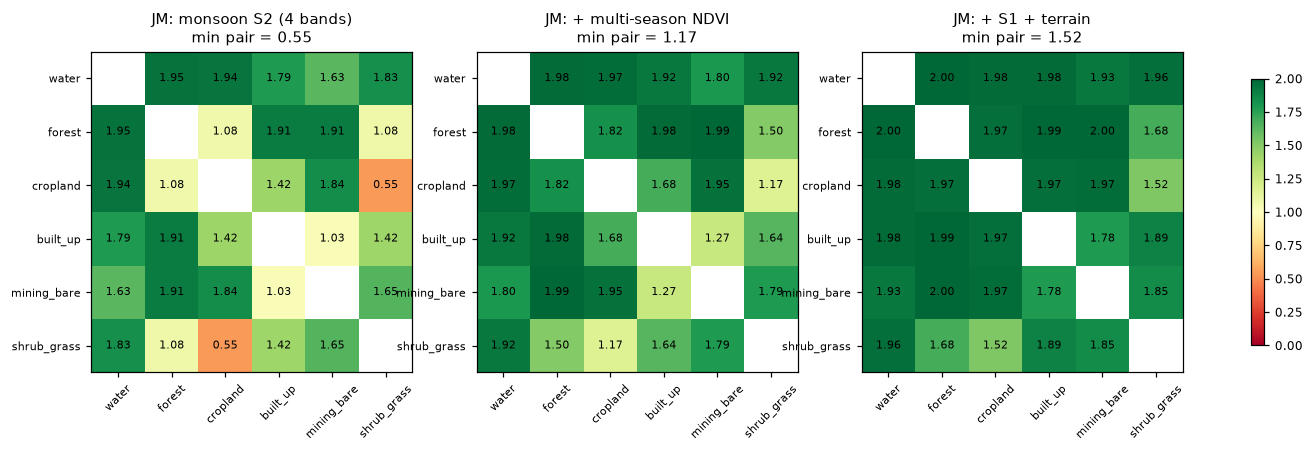

In [10]:
def jeffries_matusita(Xa, Xb):
    ma, mb = Xa.mean(0), Xb.mean(0); Sa, Sb = np.cov(Xa, rowvar=False), np.cov(Xb, rowvar=False)
    S = (Sa + Sb) / 2 + 1e-9 * np.eye(len(ma)); d = ma - mb
    B = d @ np.linalg.solve(S, d) / 8 + 0.5 * (np.linalg.slogdet(S)[1] - 0.5 * (np.linalg.slogdet(Sa + 1e-9 * np.eye(len(ma)))[1] + np.linalg.slogdet(Sb + 1e-9 * np.eye(len(ma)))[1]))
    return 2 * (1 - np.exp(-B))

sets = {"monsoon S2 (4 bands)": ["monsoon_B3", "monsoon_B4", "monsoon_B8", "monsoon_B11"],
        "+ multi-season NDVI": ["monsoon_B3", "monsoon_B4", "monsoon_B8", "monsoon_B11", "winter_NDVI", "premonsoon_NDVI", "postmonsoon_NDVI"],
        "+ S1 + terrain": ["monsoon_B3", "monsoon_B4", "monsoon_B8", "monsoon_B11", "winter_NDVI", "premonsoon_NDVI", "postmonsoon_NDVI", "monsoon_VH", "monsoon_VV", "slope_deg"]}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nm, cols) in zip(axes, sets.items()):
    J = np.full((6, 6), np.nan)
    for i in range(6):
        for j in range(6):
            if i != j: J[i, j] = jeffries_matusita(train.loc[train.class_id == i, cols].values, train.loc[train.class_id == j, cols].values)
    im = ax.imshow(J, vmin=0, vmax=2, cmap="RdYlGn")
    for i in range(6):
        for j in range(6):
            if i != j: ax.text(j, i, f"{J[i, j]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_xticks(range(6), ru.LC_CLASSES, rotation=45, fontsize=7); ax.set_yticks(range(6), ru.LC_CLASSES, fontsize=7)
    ax.set_title(f"JM: {nm}\nmin pair = {np.nanmin(J):.2f}")
fig.colorbar(im, ax=axes, shrink=0.7); plt.show()

Look at the weakest pairs (forest vs shrub, cropland vs shrub) and at how multi-season NDVI and SAR raise them. This is the quantitative argument for the feature set. Day 90 tests the same question with classifiers (the ablation study).

## **9. Redundancy Filtering**
Many features are almost duplicates (B8 and B8A, NDVI in neighbouring seasons). Redundancy does not hurt random forests much, but it inflates SHAP and importance spreads and slows SVM and MLP. We cluster features by Spearman correlation and keep one per cluster with |rho| > 0.95. This step **does not use labels**, so doing it once on the training table does not leak information into the CV.

In [11]:
rho = train[fnames].corr(method="spearman").abs().fillna(0).to_numpy(copy=True)
np.fill_diagonal(rho, 1)
Z = hierarchy.linkage(squareform(1 - rho, checks=False), method="average")
clusters = hierarchy.fcluster(Z, t=1 - config["corr_threshold"], criterion="distance")
keep = [fnames[np.flatnonzero(clusters == k)[0]] for k in np.unique(clusters)]       # first member (feature order = priority)
keep = [f for f in fnames if f in keep]
print(f"{len(fnames)} features -> {len(keep)} after removing |rho| > {config['corr_threshold']}")
feature_info = {"all": fnames, "groups": dict(zip(fnames, fgroups)), "reduced": keep}
(PROJ / "data/feature_list.json").write_text(json.dumps(feature_info, indent=1))
print("saved", PROJ / "data/feature_list.json")

81 features -> 68 after removing |rho| > 0.95
saved project1_lulc\data\feature_list.json


## **Practice Problems**
1. Add a **red-edge position** proxy, (B6 - B5) / (B7 - B5) for the monsoon season, to `lulc_features.py`. Does it separate forest from shrub (JM on that single feature)?
2. Count how many reference points fall within 40 m (two pixels) of a class boundary in the truth map. Why do such points cause label "noise" even with perfect interpreters?
3. Make Fig. 1(b) as a **true-colour** composite instead, and save both versions. Which would we put in the paper, and why?
4. *(Advanced)* Change the flagging threshold of the label-QC step to 0.05, 0.15 and 0.3 and plot precision (share of flagged that are true errors) against recall (share of errors caught).

In [12]:
# Solution 1
mon = lambda bnd: train[f"monsoon_{bnd}"].values
rep = (mon("B6") - mon("B5")) / (mon("B7") - mon("B5") + 1e-6)
print(f"JM forest vs shrub on the red-edge proxy alone: {jeffries_matusita(rep[ytr == 1, None], rep[ytr == 5, None]):.3f}; "
      f"on monsoon NDVI alone: {jeffries_matusita(train.loc[ytr == 1, ['monsoon_NDVI']].values, train.loc[ytr == 5, ['monsoon_NDVI']].values):.3f}")

JM forest vs shrub on the red-edge proxy alone: 0.172; on monsoon NDVI alone: 0.617


In [13]:
# Solution 2
from scipy.ndimage import maximum_filter, minimum_filter
edge = (maximum_filter(truth, 5) != minimum_filter(truth, 5))
near = edge[train["row"], train["col"]]
print(f"{near.mean():.0%} of points lie within 2 pixels of a boundary; label error rate there {truly_wrong[near].mean():.1%} vs {truly_wrong[~near].mean():.1%} elsewhere")

52% of points lie within 2 pixels of a boundary; label error rate there 9.0% vs 1.0% elsewhere


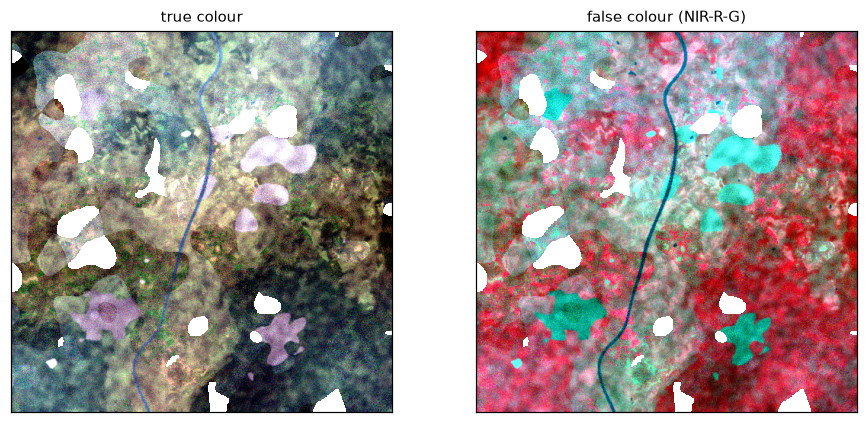

False colour separates vegetation types and water far better, so it carries more information for a land-cover paper.


In [14]:
# Solution 3
with rasterio.open(RAW / "feature_stack_2024.tif") as src:
    tcc = np.dstack([src.read(bnames.index(f"monsoon_{bb}") + 1) for bb in ("B4", "B3", "B2")])
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, img, t in [(axes[0], stretch(tcc), "true colour"), (axes[1], stretch(fcc), "false colour (NIR-R-G)")]:
    ax.imshow(img, extent=ext); ax.set_title(t); ax.set_xticks([]); ax.set_yticks([])
fig.savefig(PROJ / "outputs/figures/fig1b_true_vs_false_colour.png", dpi=300, bbox_inches="tight"); plt.show()
print("False colour separates vegetation types and water far better, so it carries more information for a land-cover paper.")

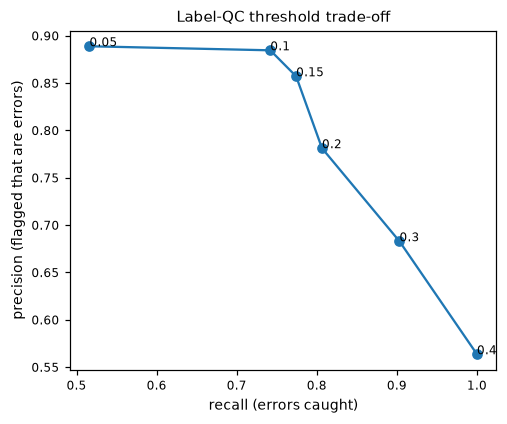

In [15]:
# Solution 4
ths = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
prec = [truly_wrong[p_given < t].mean() if (p_given < t).any() else np.nan for t in ths]
rec = [(p_given[truly_wrong] < t).mean() for t in ths]
plt.figure(figsize=(5, 4)); plt.plot(rec, prec, "-o")
for t, a_, b_ in zip(ths, rec, prec): plt.annotate(str(t), (a_, b_), fontsize=8)
plt.xlabel("recall (errors caught)"); plt.ylabel("precision (flagged that are errors)"); plt.title("Label-QC threshold trade-off"); plt.show()

## **Key References**
- Gómez, C., White, J. C., & Wulder, M. A. (2016). Optical remotely sensed time series data for land cover classification: A review. *ISPRS Journal of Photogrammetry and Remote Sensing*, 116, 55-72.
- Belgiu, M., & Drăguţ, L. (2016). Random forest in remote sensing: A review of applications and future directions. *ISPRS Journal of Photogrammetry and Remote Sensing*, 114, 24-31.
- Haralick, R. M., Shanmugam, K., & Dinstein, I. (1973). Textural features for image classification. *IEEE Transactions on Systems, Man, and Cybernetics*, SMC-3(6), 610-621.
- Richards, J. A. (2013). *Remote Sensing Digital Image Analysis* (5th ed.). Springer (Jeffries-Matusita distance).
- Northcutt, C., Jiang, L., & Chuang, I. (2021). Confident learning: Estimating uncertainty in dataset labels. *Journal of Artificial Intelligence Research*, 70, 1373-1411.
- Zanaga, D. et al. (2022). ESA WorldCover 10 m 2021 v200. Zenodo. doi:10.5281/zenodo.7254221.
- Brown, C. F. et al. (2022). Dynamic World, near real-time global 10 m land use land cover mapping. *Scientific Data*, 9, 251.